# RL Traffic Signal Control: walkthrough

This notebook walks through the project end to end: the environment, the exact optimal policy, training both agents, and evaluating them against classic signal timing. The full, multi-seed experiment lives in `train.py`; this notebook uses a single seed so it runs in under a minute.

In [1]:
import sys, numpy as np, matplotlib.pyplot as plt
sys.path.insert(0, '..')
from traffic_rl import TrafficIntersectionEnv
from traffic_rl.agents import (Hyperparams, q_learning, monte_carlo, value_iteration, greedy_policy,
                               policy_from_table, evaluate, fixed_time_policy, longest_queue_policy, random_policy)

## 1. The environment
Two queues (North–South up to 3 cars, East–West up to 5). Each tick 0–2 cars arrive per road, the green road discharges 1–2, and the reward is minus the number of cars waiting.

In [2]:
env = TrafficIntersectionEnv(render_mode='ansi')
obs, _ = env.reset(seed=42)
for _ in range(6):
    obs, r, term, trunc, info = env.step(env.action_space.sample())
    print(env.render(), '  reward', r)

t=01  NS     0   EW █████ 5   reward -5.0
t=02  NS     0   EW █████ 5   reward -5.0
t=03  NS     0   EW ███   3   reward -3.0
t=04  NS ██  2   EW ███   3   reward -5.0
t=05  NS ███ 3   EW ███   3   reward -6.0
t=06  NS ███ 3   EW ████  4   reward -7.0


## 2. Ground truth: value iteration
With 24 states and a known model, the MDP can be solved exactly. Action 0 = East–West green, 1 = North–South green.

In [3]:
Q_star = value_iteration(gamma=0.9)
pi_star = greedy_policy(Q_star)
print('optimal action per state (rows = NS cars 0..3, cols = EW cars 0..5):')
print(pi_star)

optimal action per state (rows = NS cars 0..3, cols = EW cars 0..5):
[[0 0 0 0 0 0]
 [1 0 0 0 0 0]
 [1 0 0 0 0 0]
 [0 0 0 0 0 0]]


## 3. Train both agents (report settings: α 0.1, γ 0.9, ε 1.0 → 0.01, decay 0.995, 5,000 episodes)

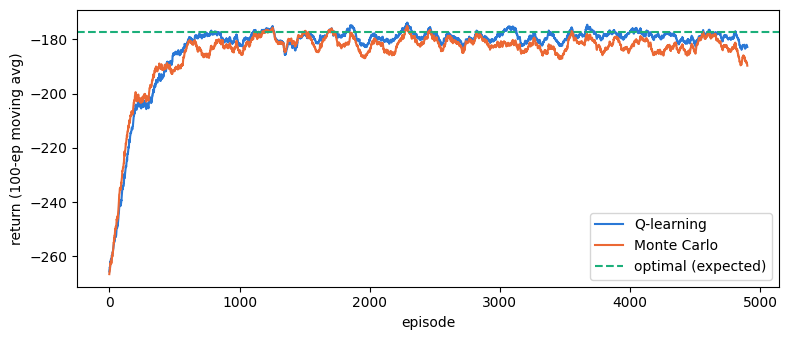

In [4]:
hp = Hyperparams()
Q_q, r_q = q_learning(hp, seed=0)
Q_mc, r_mc = monte_carlo(hp, seed=0)
smooth = lambda x: np.convolve(x, np.ones(100) / 100, mode='valid')
plt.figure(figsize=(8, 3.5))
plt.plot(smooth(r_q), color='#2a78d6', label='Q-learning')
plt.plot(smooth(r_mc), color='#eb6834', label='Monte Carlo')
plt.axhline(-50 * evaluate(policy_from_table(pi_star), 500)[0], color='#1baf7a', ls='--', label='optimal (expected)')
plt.xlabel('episode'); plt.ylabel('return (100-ep moving avg)'); plt.legend(); plt.tight_layout()

## 4. Evaluate on identical held-out traffic

In [5]:
policies = {
    'Optimal': policy_from_table(pi_star),
    'Q-learning': policy_from_table(greedy_policy(Q_q)),
    'Monte Carlo': policy_from_table(greedy_policy(Q_mc)),
    'Longest queue first': longest_queue_policy(),
    'Random': random_policy(np.random.default_rng(7)),
    'Fixed-time': fixed_time_policy(2),
}
for name, pol in policies.items():
    m, ci = evaluate(pol, episodes=1000)
    d, _ = evaluate(pol, episodes=1000, metric='dropped')
    print(f'{name:22s} {m:.3f} ± {ci:.3f} cars waiting   {d:.3f} turned away / tick')
print('\nQ-learning matches the optimal action in', f'{(greedy_policy(Q_q) == pi_star).mean():.0%}', 'of states')

Optimal                3.545 ± 0.023 cars waiting   0.958 turned away / tick


Q-learning             3.547 ± 0.022 cars waiting   0.967 turned away / tick


Monte Carlo            3.556 ± 0.023 cars waiting   0.962 turned away / tick


Longest queue first    5.045 ± 0.038 cars waiting   0.488 turned away / tick


Random                 5.492 ± 0.041 cars waiting   0.563 turned away / tick


Fixed-time             5.702 ± 0.040 cars waiting   0.506 turned away / tick

Q-learning matches the optimal action in 92% of states


## 5. Takeaways
* Both agents converge to within a few hundredths of a car of the optimal policy and cut waiting by roughly a third versus fixed-time signals.
* Q-learning converges faster and more consistently across seeds than first-visit Monte Carlo.
* The optimal policy almost always keeps East–West green: cars arriving at a full North–South queue leave the model and the original reward never counts them. `TrafficIntersectionEnv(overflow_penalty=2)` fixes that; see `train.py` and the README for the comparison.